# Notebook 01: Data Collection and Curation
## Domain Shift and Scaffold Generalization Failure in QSAR Models Applied to Natural Product Chemical Space

**Author:** Abubakar Siddiq Salihu  
**Affiliation:** Department of Pure and Industrial Chemistry, Umaru Musa Yar'adua University, Katsina, Nigeria  
**Date:** 2026  

---

### What this notebook does

This notebook handles all data collection and curation steps:

1. Extracts bioactivity data for three targets from ChEMBL 36 (local SQLite)
2. Processes the COCONUT 2.0 natural products dataset
3. Standardizes all molecules using RDKit
4. Assigns NP-likeness scores to all compounds
5. Removes duplicates and data leakage between sets
6. Exports clean CSV files ready for Notebook 02 (modeling)

**Targets selected:**
- Acetylcholinesterase (AChE) - CHEMBL220
- InhA / Enoyl-ACP reductase - CHEMBL2366452  
- Cyclooxygenase-2 (COX-2) - CHEMBL230

**Run environment:** Local machine (Anaconda/Jupyter)  
**Estimated runtime:** 15-30 minutes depending on hardware

---

## Cell 00: Environment Setup

In [1]:
# ============================================================
# CELL 00: Environment Setup
# Install any missing packages before proceeding
# Run this cell first, restart kernel if packages were installed
# ============================================================

import subprocess
import sys

required_packages = [
    'rdkit',
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'tqdm'
]

for pkg in required_packages:
    try:
        __import__(pkg if pkg != 'rdkit' else 'rdkit.Chem')
        print(f'  [OK] {pkg}')
    except ImportError:
        print(f'  [INSTALLING] {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('\nAll packages available. Proceed to Cell 01.')

  [OK] rdkit
  [OK] pandas
  [OK] numpy
  [OK] matplotlib
  [OK] seaborn
  [INSTALLING] scikit-learn...
  [OK] tqdm

All packages available. Proceed to Cell 01.


## Cell 01: Imports and Configuration

In [2]:
# ============================================================
# CELL 01: Imports and Global Configuration
# All imports are here. If any import fails, return to Cell 00.
# ============================================================

import os
import sqlite3
import warnings
import hashlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm

# RDKit imports
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import (
    Descriptors, AllChem, MACCSkeys,
    rdMolDescriptors, Scaffolds
)
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

# Suppress RDKit warnings for cleaner output
# These are expected during large-scale SMILES processing
RDLogger.DisableLog('rdApp.*')
warnings.filterwarnings('ignore')

# ---- GLOBAL CONFIGURATION ----
# Edit these paths to match your local setup

CONFIG = {
    # Path to extracted ChEMBL 36 SQLite file
    'chembl_db': r'C:\Users\PC\Documents\inha_qsar_project\data\chembl_36\chembl_36_sqlite\chembl_36.db',  # EDIT THIS

    # Path to extracted COCONUT lite CSV
    'coconut_csv': r'C:\Users\PC\Documents\inha_qsar_project\Domain shift\coconut_csv_lite-05-2026.csv',  # EDIT THIS

    # Output directory - will be created if it does not exist
    'output_dir': r'C:\Users\PC\Documents\inha_qsar_project\Domain shift\np_qsar_project\data',  # EDIT THIS

    # ChEMBL target IDs
    # AChE, InhA, COX-2
    'targets': {
    'AChE':  'CHEMBL220',
    '5LOX':  'CHEMBL215',
    'COX2':  'CHEMBL230'
},

    # Activity thresholds
    'pchembl_min': 5.0,       # Minimum pChEMBL (10 uM cutoff)
    'pchembl_active': 6.0,    # Active threshold (1 uM cutoff)

    # NP-likeness threshold for COCONUT filtering
    'np_likeness_threshold': 0.5,

    # Minimum compounds per target to proceed
    'min_compounds_chembl': 200,
    'min_compounds_np': 50,

    # Random seed for reproducibility
    'seed': 42
}

# ---- Create output directory ----
Path(CONFIG['output_dir']).mkdir(parents=True, exist_ok=True)

# ---- Session log ----
print('=' * 60)
print('NP-QSAR Domain Shift Study')
print('Notebook 01: Data Curation')
print(f"Session started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print('=' * 60)
print(f"ChEMBL DB   : {CONFIG['chembl_db']}")
print(f"COCONUT CSV : {CONFIG['coconut_csv']}")
print(f"Output dir  : {CONFIG['output_dir']}")
print(f"Targets     : {list(CONFIG['targets'].keys())}")
print('=' * 60)

# Verify files exist before proceeding
errors = []
if not Path(CONFIG['chembl_db']).exists():
    errors.append(f"ChEMBL database not found: {CONFIG['chembl_db']}")
if not Path(CONFIG['coconut_csv']).exists():
    errors.append(f"COCONUT CSV not found: {CONFIG['coconut_csv']}")

if errors:
    for e in errors:
        print(f'[ERROR] {e}')
    print('\nUpdate CONFIG paths above and re-run this cell.')
else:
    print('[OK] All input files found. Ready to proceed.')

NP-QSAR Domain Shift Study
Notebook 01: Data Curation
Session started: 2026-05-01 16:02:24
ChEMBL DB   : C:\Users\PC\Documents\inha_qsar_project\data\chembl_36\chembl_36_sqlite\chembl_36.db
COCONUT CSV : C:\Users\PC\Documents\inha_qsar_project\Domain shift\coconut_csv_lite-05-2026.csv
Output dir  : C:\Users\PC\Documents\inha_qsar_project\Domain shift\np_qsar_project\data
Targets     : ['AChE', '5LOX', 'COX2']
[OK] All input files found. Ready to proceed.


## Cell 02: Molecule Standardization Functions

All SMILES processing passes through a single standardization pipeline. This ensures consistency between ChEMBL and COCONUT compounds.

In [3]:
# ============================================================
# CELL 02: Molecule Standardization Functions
#
# A single standardization pipeline is applied to ALL compounds
# from both ChEMBL and COCONUT. This is critical: inconsistent
# standardization is one of the most common sources of data
# leakage and inflated performance in published QSAR studies.
# ============================================================

def standardize_smiles(smiles: str) -> str | None:
    """
    Standardize a SMILES string using RDKit.

    Steps applied:
    1. Parse SMILES to RDKit molecule
    2. Remove salts/fragments (keep largest fragment)
    3. Neutralize charges where possible
    4. Convert back to canonical SMILES

    Returns None if the molecule cannot be parsed or standardized.
    This is intentional: failed molecules are dropped, not imputed.
    """
    if pd.isna(smiles) or not isinstance(smiles, str) or len(smiles.strip()) == 0:
        return None

    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None

        # Step 1: Keep largest fragment (removes salts and counterions)
        frags = Chem.GetMolFrags(mol, asMols=True)
        if len(frags) > 1:
            mol = max(frags, key=lambda m: m.GetNumHeavyAtoms())

        # Step 2: Basic neutralization
        # Replace charged atoms with neutral equivalents where unambiguous
        mol = neutralize_molecule(mol)
        if mol is None:
            return None

        # Step 3: Remove explicit Hs, sanitize
        mol = Chem.RemoveHs(mol)
        Chem.SanitizeMol(mol)

        # Step 4: Filter by size - remove fragments too small to be drugs
        if mol.GetNumHeavyAtoms() < 7:
            return None

        return Chem.MolToSmiles(mol, canonical=True)

    except Exception:
        return None


def neutralize_molecule(mol):
    """
    Neutralize common charged groups.
    Based on the Scharfer-Schwab neutralization approach.
    """
    try:
        # SMARTS patterns: (charged pattern, neutral replacement)
        neutralization_patterns = [
            ('[n+;H]', 'n'),
            ('[N+;!H0]', 'N'),
            ('[$([O-]);!$([O-][#7])]', 'O'),
            ('[S-;X1]', 'S'),
            ('[$([N-;X2]S(=O)=O)]', 'N'),
            ('[$([N-;X3](C(=O))(C(=O)))]', 'N'),
            ('[n-]', '[nH]'),
        ]
        from rdkit.Chem import AllChem
        for smarts, replacement in neutralization_patterns:
            pattern = Chem.MolFromSmarts(smarts)
            if pattern and mol.HasSubstructMatch(pattern):
                repl = Chem.MolFromSmiles(replacement)
                if repl:
                    mol = AllChem.ReplaceSubstructs(
                        mol, pattern, repl, replaceAll=True
                    )[0]
        Chem.SanitizeMol(mol)
        return mol
    except Exception:
        return mol  # Return original if neutralization fails


def smiles_to_inchikey(smiles: str) -> str | None:
    """
    Convert standardized SMILES to InChIKey.
    
    RDKit 2025.x: MolToInchiKey accepts a Mol object directly,
    NOT an InChI string. This is different from older RDKit versions
    where the pipeline was SMILES -> InChI string -> InChIKey string.
    The correct pipeline for RDKit >= 2022.x is:
    SMILES -> Mol -> InChIKey directly via MolToInchiKey(mol)
    """
    try:
        from rdkit.Chem.inchi import MolToInchiKey
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        key = MolToInchiKey(mol)
        return key if key else None
    except Exception:
        return None


def get_murcko_scaffold(smiles: str) -> str | None:
    """
    Generate Bemis-Murcko scaffold for scaffold-based splitting.
    Returns generic scaffold SMILES or None if generation fails.
    """
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold, canonical=True)
    except Exception:
        return None


# Quick validation test
test_cases = [
    ('Aspirin', 'CC(=O)Oc1ccccc1C(=O)O'),
    ('Galanthamine (NP)', 'O=C1OCC2CC1N(C)CCC3=CC(OC)=CC=C23'),
    ('Salt form', 'CC(=O)Oc1ccccc1C(=O)[O-].[Na+]'),
    ('Invalid SMILES', 'not_a_smiles'),
]

print('Standardization function validation:')
print('-' * 50)
for name, smi in test_cases:
    result = standardize_smiles(smi)
    inchik = smiles_to_inchikey(result) if result else None
    scaffold = get_murcko_scaffold(result) if result else None
    print(f'{name}')
    print(f'  Input    : {smi[:50]}')
    print(f'  Standard : {result}')
    print(f'  InChIKey : {inchik}')
    print(f'  Scaffold : {scaffold}')
    print()

print('[OK] Standardization functions ready.')

Standardization function validation:
--------------------------------------------------
Aspirin
  Input    : CC(=O)Oc1ccccc1C(=O)O
  Standard : CC(=O)Oc1ccccc1C(=O)O
  InChIKey : BSYNRYMUTXBXSQ-UHFFFAOYSA-N
  Scaffold : c1ccccc1

Galanthamine (NP)
  Input    : O=C1OCC2CC1N(C)CCC3=CC(OC)=CC=C23
  Standard : COc1ccc2c(c1)CCN(C)C1CC2COC1=O
  InChIKey : IMRKPGKMZIZEEO-UHFFFAOYSA-N
  Scaffold : O=C1OCC2CC1NCCc1ccccc12

Salt form
  Input    : CC(=O)Oc1ccccc1C(=O)[O-].[Na+]
  Standard : CC(=O)Oc1ccccc1C(=O)O
  InChIKey : BSYNRYMUTXBXSQ-UHFFFAOYSA-N
  Scaffold : c1ccccc1

Invalid SMILES
  Input    : not_a_smiles
  Standard : None
  InChIKey : None
  Scaffold : None

[OK] Standardization functions ready.


In [4]:
# Verify the fix works before re-running the full pipeline
test = smiles_to_inchikey('CC(=O)Oc1ccccc1C(=O)O')
print(f'Aspirin InChIKey: {test}')
# Expected: BSYNRYMUTXBXSQ-UHFFFAOYSA-N
assert test == 'BSYNRYMUTXBXSQ-UHFFFAOYSA-N', 'Fix did not work'
print('[OK] InChIKey generation working correctly.')

Aspirin InChIKey: BSYNRYMUTXBXSQ-UHFFFAOYSA-N
[OK] InChIKey generation working correctly.


## Cell 03: ChEMBL Data Extraction

Direct SQL queries against ChEMBL 36 SQLite. Each query is documented so the exact data provenance is clear for the Methods section.

In [5]:
# ============================================================
# DIAGNOSTIC CELL - run this before anything else
# Paste directly after Cell 02 and run it
# ============================================================

from rdkit.Chem.inchi import MolToInchi, MolToInchiKey

# Test 1: Does RDKit inchi module work on your installation?
test_smiles = [
    'CC(=O)Oc1ccccc1C(=O)O',          # Aspirin
    'OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O',  # Glucose
    'c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34',  # Pyrene
]

print('Testing RDKit InChI generation:')
print('-' * 50)
for smi in test_smiles:
    mol = Chem.MolFromSmiles(smi)
    print(f'SMILES   : {smi[:40]}')
    print(f'Mol      : {mol}')
    if mol:
        try:
            inchi = MolToInchi(mol)
            print(f'InChI    : {inchi[:60] if inchi else None}')
            if inchi:
                key = MolToInchiKey(inchi)
                print(f'InChIKey : {key}')
            else:
                print('InChIKey : FAILED - InChI is None')
        except Exception as e:
            print(f'ERROR    : {e}')
    print()

# Test 2: Check what InChI module is available
print('\nChecking available InChI import paths:')
import importlib
for path in [
    'rdkit.Chem.inchi',
    'rdkit.Chem.InchiInfo',
    'rdkit.Chem.rdinchi',
]:
    try:
        mod = importlib.import_module(path)
        print(f'  [OK] {path}: {dir(mod)}')
    except ImportError as e:
        print(f'  [FAIL] {path}: {e}')

# Test 3: Check RDKit version
from rdkit import __version__ as rdkit_version
print(f'\nRDKit version: {rdkit_version}')

Testing RDKit InChI generation:
--------------------------------------------------
SMILES   : CC(=O)Oc1ccccc1C(=O)O
Mol      : <rdkit.Chem.rdchem.Mol object at 0x000001CF0E6A50E0>
InChI    : InChI=1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)12/h2-5H,1H3,(
ERROR    : Python argument types in
    rdkit.Chem.rdinchi.MolToInchiKey(str, str)
did not match C++ signature:
    MolToInchiKey(class RDKit::ROMol mol, char const * __ptr64 options='')

SMILES   : OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O
Mol      : <rdkit.Chem.rdchem.Mol object at 0x000001CF0E6A5850>
InChI    : InChI=1S/C6H12O6/c7-1-2-3(8)4(9)5(10)6(11)12-2/h2-11H,1H2/t2
ERROR    : Python argument types in
    rdkit.Chem.rdinchi.MolToInchiKey(str, str)
did not match C++ signature:
    MolToInchiKey(class RDKit::ROMol mol, char const * __ptr64 options='')

SMILES   : c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34
Mol      : <rdkit.Chem.rdchem.Mol object at 0x000001CF0E6A5A10>
InChI    : InChI=1S/C20H12/c1-2-7-17-15(4-1)12-16-9-8-13-5-3-6-14-10-11
ERROR 

In [6]:
# ============================================================
# CELL 03: ChEMBL Data Extraction
#
# SQL query design rationale:
# - Single protein targets only (target_type = 'SINGLE PROTEIN')
# - Standard IC50 and Ki values only (avoids Kd, EC50 mixing)
# - pChEMBL value required (pre-converted to -log10 scale by ChEMBL)
# - Confidence score >= 8 (direct target assignment, not inferred)
# - Organism = Homo sapiens for AChE and COX-2
#   (InhA is Mycobacterium tuberculosis - intentional for NTD angle)
# ============================================================

CHEMBL_QUERY = """
SELECT DISTINCT
    md.chembl_id          AS molecule_chembl_id,
    cs.canonical_smiles   AS smiles,
    act.pchembl_value     AS pchembl_value,
    act.standard_type     AS assay_type,
    act.standard_units    AS units,
    td.chembl_id          AS target_chembl_id,
    td.pref_name          AS target_name,
    cp.np_likeness_score  AS np_likeness_score
FROM
    activities act
    JOIN molecule_dictionary md  ON act.molregno = md.molregno
    JOIN compound_structures cs  ON md.molregno = cs.molregno
    JOIN assays ass              ON act.assay_id = ass.assay_id
    JOIN target_dictionary td    ON ass.tid = td.tid
    LEFT JOIN compound_properties cp ON md.molregno = cp.molregno
WHERE
    td.chembl_id = ?
    AND td.target_type = 'SINGLE PROTEIN'
    AND act.standard_type IN ('IC50', 'Ki')
    AND act.pchembl_value IS NOT NULL
    AND act.pchembl_value >= ?
    AND act.data_validity_comment IS NULL
    AND ass.confidence_score >= 8
    AND cs.canonical_smiles IS NOT NULL
"""


def extract_chembl_target(db_path: str, target_id: str,
                           pchembl_min: float = 5.0) -> pd.DataFrame:
    """
    Extract bioactivity data for a single target from ChEMBL SQLite.

    Parameters
    ----------
    db_path : str
        Path to ChEMBL SQLite database file
    target_id : str
        ChEMBL target ID (e.g., 'CHEMBL220')
    pchembl_min : float
        Minimum pChEMBL value filter

    Returns
    -------
    pd.DataFrame with raw query results
    """
    conn = sqlite3.connect(db_path)
    try:
        df = pd.read_sql_query(
            CHEMBL_QUERY,
            conn,
            params=(target_id, pchembl_min)
        )
        return df
    finally:
        conn.close()


def process_chembl_target(df_raw: pd.DataFrame,
                           target_name: str,
                           pchembl_active: float = 6.0) -> pd.DataFrame:
    """
    Process raw ChEMBL query results into a clean, analysis-ready DataFrame.

    Steps:
    1. Standardize SMILES
    2. Generate InChIKeys for deduplication
    3. Handle duplicate molecules (keep median pChEMBL)
    4. Assign binary activity labels
    5. Generate Murcko scaffolds
    6. Add source and target metadata
    """
    print(f'  Processing {target_name}: {len(df_raw)} raw records')

    # Step 1: Standardize SMILES
    tqdm.pandas(desc=f'  Standardizing {target_name}')
    df_raw['std_smiles'] = df_raw['smiles'].progress_apply(standardize_smiles)

    # Drop failed standardizations
    n_before = len(df_raw)
    df_raw = df_raw.dropna(subset=['std_smiles'])
    n_after = len(df_raw)
    print(f'  Dropped {n_before - n_after} molecules (standardization failed)')

    # Step 2: Generate InChIKeys
    df_raw['inchikey'] = df_raw['std_smiles'].apply(smiles_to_inchikey)
    df_raw = df_raw.dropna(subset=['inchikey'])

    # Step 3: Handle duplicate molecules
    # Multiple assay measurements for the same compound are common in ChEMBL.
    # Strategy: take the median pChEMBL value per InChIKey.
    # This is more conservative than taking max (avoids outlier inflation)
    # and more informative than taking min.
    df_raw['pchembl_value'] = pd.to_numeric(df_raw['pchembl_value'],
                                            errors='coerce')
    df_dedup = (
        df_raw.groupby('inchikey')
        .agg(
            std_smiles=('std_smiles', 'first'),
            pchembl_value=('pchembl_value', 'median'),
            molecule_chembl_id=('molecule_chembl_id', 'first'),
            np_likeness_score=('np_likeness_score', 'first')
        )
        .reset_index()
    )
    print(f'  After deduplication: {len(df_dedup)} unique molecules')

    # Step 4: Binary activity labeling
    # Active: pChEMBL >= 6.0 (IC50/Ki <= 1 uM)
    # Inactive: pChEMBL < 6.0 (IC50/Ki > 1 uM)
    df_dedup['activity'] = (df_dedup['pchembl_value'] >= pchembl_active
                            ).astype(int)

    # Step 5: Murcko scaffolds for scaffold splitting
    df_dedup['scaffold'] = df_dedup['std_smiles'].apply(get_murcko_scaffold)

    # Step 6: Metadata
    df_dedup['target'] = target_name
    df_dedup['source'] = 'ChEMBL36'
    df_dedup['compound_type'] = 'synthetic'

    # Class balance report
    n_active = df_dedup['activity'].sum()
    n_inactive = len(df_dedup) - n_active
    ratio = n_active / max(n_inactive, 1)
    print(f'  Active: {n_active} | Inactive: {n_inactive} | '
          f'Ratio: {ratio:.2f}')

    return df_dedup


# ---- Extract all three targets ----
print('Extracting ChEMBL data for all targets...')
print('=' * 60)

chembl_dfs = {}

for target_name, target_id in CONFIG['targets'].items():
    print(f'\nTarget: {target_name} ({target_id})')
    try:
        df_raw = extract_chembl_target(
            CONFIG['chembl_db'],
            target_id,
            CONFIG['pchembl_min']
        )
        if len(df_raw) == 0:
            print(f'  [WARNING] No data returned for {target_id}')
            print(f'  Check that target ID is correct in ChEMBL 36')
            continue

        df_processed = process_chembl_target(
            df_raw, target_name, CONFIG['pchembl_active']
        )

        # Enforce minimum compound requirement
        if len(df_processed) < CONFIG['min_compounds_chembl']:
            print(f'  [WARNING] Only {len(df_processed)} compounds for '
                  f'{target_name}. Minimum is '
                  f"{CONFIG['min_compounds_chembl']}.")
            print(f'  Consider relaxing pchembl_min or changing target.')

        chembl_dfs[target_name] = df_processed
        print(f'  [OK] {target_name}: {len(df_processed)} compounds ready')

    except Exception as e:
        print(f'  [ERROR] Failed for {target_name}: {e}')

print('\n' + '=' * 60)
print(f'ChEMBL extraction complete. Targets loaded: '
      f'{list(chembl_dfs.keys())}')

Extracting ChEMBL data for all targets...

Target: AChE (CHEMBL220)
  Processing AChE: 5633 raw records


  Standardizing AChE: 100%|███████████████████████████████████████████████████████| 5633/5633 [00:21<00:00, 258.10it/s]


  Dropped 0 molecules (standardization failed)
  After deduplication: 4661 unique molecules
  Active: 2889 | Inactive: 1772 | Ratio: 1.63
  [OK] AChE: 4661 compounds ready

Target: 5LOX (CHEMBL215)
  Processing 5LOX: 2984 raw records


  Standardizing 5LOX: 100%|███████████████████████████████████████████████████████| 2984/2984 [00:10<00:00, 277.75it/s]


  Dropped 0 molecules (standardization failed)
  After deduplication: 2128 unique molecules
  Active: 1303 | Inactive: 825 | Ratio: 1.58
  [OK] 5LOX: 2128 compounds ready

Target: COX2 (CHEMBL230)
  Processing COX2: 4394 raw records


  Standardizing COX2: 100%|███████████████████████████████████████████████████████| 4394/4394 [00:13<00:00, 320.09it/s]


  Dropped 0 molecules (standardization failed)
  After deduplication: 3690 unique molecules
  Active: 2440 | Inactive: 1250 | Ratio: 1.95
  [OK] COX2: 3690 compounds ready

ChEMBL extraction complete. Targets loaded: ['AChE', '5LOX', 'COX2']


## Cell 04: COCONUT Natural Products Processing

In [7]:
# ============================================================
# CELL 04: COCONUT 2.0 Natural Products Processing
#
# COCONUT 2.0 (May 2026) contains ~500,000+ natural products.
# The lite CSV includes canonical SMILES, InChIKey, molecular
# formula, and NP-likeness score among other fields.
#
# Our goal here is not to use COCONUT bioactivity directly
# (COCONUT is primarily a structure database, not bioactivity).
# Instead, we use COCONUT to define what constitutes NP chemical
# space, then cross-reference with ChEMBL NP-annotated entries
# to find NPs with confirmed bioactivity against our targets.
# ============================================================

print('Loading COCONUT 2.0 lite CSV...')
print('This may take 1-2 minutes for ~500k compounds')

# Load with explicit dtypes for memory efficiency
coconut_raw = pd.read_csv(
    CONFIG['coconut_csv'],
    low_memory=False
)

print(f'Raw COCONUT records: {len(coconut_raw):,}')
print(f'Columns available: {list(coconut_raw.columns)}')

# ---- Identify SMILES column ----
# COCONUT 2.0 column names may vary. Find the SMILES column.
smiles_col_candidates = [
    col for col in coconut_raw.columns
    if 'smiles' in col.lower() or 'canonical' in col.lower()
]
print(f'SMILES column candidates: {smiles_col_candidates}')

# Use first candidate; update if needed
COCONUT_SMILES_COL = smiles_col_candidates[0] if smiles_col_candidates else 'canonical_smiles'
print(f'Using SMILES column: {COCONUT_SMILES_COL}')

# ---- Identify NP-likeness score column ----
np_score_candidates = [
    col for col in coconut_raw.columns
    if 'np' in col.lower() and ('score' in col.lower() or 'likeness' in col.lower())
]
print(f'NP-score column candidates: {np_score_candidates}')

Loading COCONUT 2.0 lite CSV...
This may take 1-2 minutes for ~500k compounds
Raw COCONUT records: 738,827
Columns available: ['id', 'identifier', 'canonical_smiles', 'standard_inchi', 'standard_inchi_key', 'name', 'iupac_name', 'annotation_level', 'total_atom_count', 'heavy_atom_count', 'molecular_weight', 'exact_molecular_weight', 'molecular_formula', 'alogp', 'topological_polar_surface_area', 'rotatable_bond_count', 'hydrogen_bond_acceptors', 'hydrogen_bond_donors', 'hydrogen_bond_acceptors_lipinski', 'hydrogen_bond_donors_lipinski', 'lipinski_rule_of_five_violations', 'aromatic_rings_count', 'qed_drug_likeliness', 'formal_charge', 'fractioncsp3', 'number_of_minimal_rings', 'van_der_walls_volume', 'contains_sugar', 'contains_ring_sugars', 'contains_linear_sugars', 'murcko_framework', 'np_likeness', 'chemical_class', 'chemical_sub_class', 'chemical_super_class', 'direct_parent_classification', 'np_classifier_pathway', 'np_classifier_superclass', 'np_classifier_class', 'np_classifier_

COCONUT after removing null SMILES: 738,827

Standardizing COCONUT SMILES (chunked processing)...


Standardizing COCONUT: 100%|███████████████████████████████████████████████████████████| 74/74 [25:33<00:00, 20.72s/it]


Dropped 1,297 molecules (failed standardization)
COCONUT after standardization: 737,530

NP-likeness scores already present in COCONUT dataset.

Generating InChIKeys for COCONUT compounds...


  Standardizing COX2: 100%|███████████████████████████████████████████████████| 737530/737530 [23:50<00:00, 515.55it/s]


Removed 12,444 duplicates from COCONUT
Final COCONUT unique compounds: 725,086


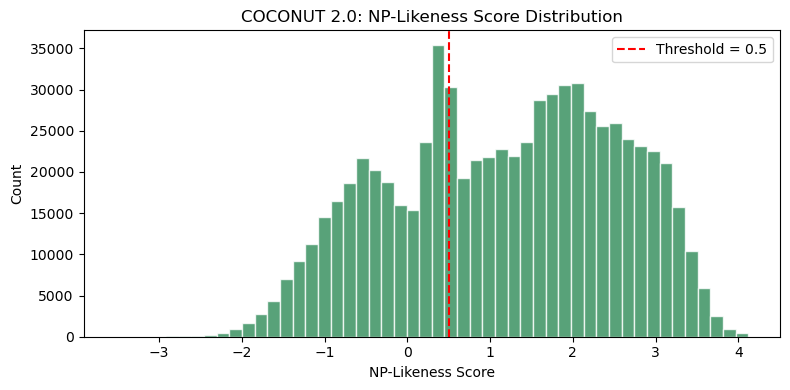

[OK] COCONUT processing complete.


In [8]:
# ============================================================
# CELL 04b: COCONUT Standardization and NP-likeness Scoring
#
# If COCONUT already provides NP-likeness scores, we use them.
# If not, we calculate them using the RDKit Ertl implementation.
# ============================================================

# ---- Check if NP-likeness score is in COCONUT ----
COCONUT_NPSCORE_COL = np_score_candidates[0] if np_score_candidates else None

# Select relevant columns
cols_to_keep = [COCONUT_SMILES_COL]
if COCONUT_NPSCORE_COL:
    cols_to_keep.append(COCONUT_NPSCORE_COL)

# Add InChIKey if present
inchikey_col = next(
    (c for c in coconut_raw.columns if 'inchikey' in c.lower()), None
)
if inchikey_col:
    cols_to_keep.append(inchikey_col)

coconut_subset = coconut_raw[cols_to_keep].copy()
coconut_subset.columns = (
    ['smiles'] +
    (['np_score'] if COCONUT_NPSCORE_COL else []) +
    (['inchikey_coconut'] if inchikey_col else [])
)

# Drop rows with missing SMILES
coconut_subset = coconut_subset.dropna(subset=['smiles'])
print(f'COCONUT after removing null SMILES: {len(coconut_subset):,}')

# ---- Standardize COCONUT SMILES ----
# Process in chunks to avoid memory issues with 500k+ compounds
print('\nStandardizing COCONUT SMILES (chunked processing)...')
CHUNK_SIZE = 10000

std_smiles_list = []
for i in tqdm(range(0, len(coconut_subset), CHUNK_SIZE),
              desc='Standardizing COCONUT'):
    chunk = coconut_subset['smiles'].iloc[i:i + CHUNK_SIZE]
    std_smiles_list.extend(chunk.apply(standardize_smiles).tolist())

coconut_subset['std_smiles'] = std_smiles_list

# Drop failed standardizations
n_before = len(coconut_subset)
coconut_subset = coconut_subset.dropna(subset=['std_smiles'])
print(f'Dropped {n_before - len(coconut_subset):,} molecules '
      f'(failed standardization)')
print(f'COCONUT after standardization: {len(coconut_subset):,}')

# ---- Calculate NP-likeness score if not already present ----
if 'np_score' not in coconut_subset.columns:
    print('\nCalculating NP-likeness scores (Ertl/RDKit)...')
    print('Note: this requires rdkit.Chem.Descriptors NP score model')
    try:
        # RDKit NP-likeness scorer
        from rdkit.Chem import RDConfig
        import os as _os
        import sys as _sys
        _sys.path.append(_os.path.join(RDConfig.RDContribDir,
                                       'SA_Score'))
        # Try the NP scorer
        npscorer_path = _os.path.join(
            RDConfig.RDContribDir, 'NP_Score', 'npscorer.py'
        )
        if _os.path.exists(npscorer_path):
            import importlib.util
            spec = importlib.util.spec_from_file_location(
                'npscorer', npscorer_path
            )
            npscorer = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(npscorer)
            fscore = npscorer.readNPModel()

            np_scores = []
            for smi in tqdm(coconut_subset['std_smiles'],
                           desc='NP scores'):
                mol = Chem.MolFromSmiles(smi)
                if mol:
                    np_scores.append(
                        npscorer.scoreMol(mol, fscore)
                    )
                else:
                    np_scores.append(None)
            coconut_subset['np_score'] = np_scores
        else:
            print('  NP scorer not found in RDKit contrib.')
            print('  Using placeholder score of 1.0 for all COCONUT compounds')
            print('  (All COCONUT compounds are natural products by definition)')
            coconut_subset['np_score'] = 1.0
    except Exception as e:
        print(f'  NP score calculation failed: {e}')
        print('  Using placeholder score of 1.0')
        coconut_subset['np_score'] = 1.0
else:
    print(f'\nNP-likeness scores already present in COCONUT dataset.')
    # Convert to numeric
    coconut_subset['np_score'] = pd.to_numeric(
        coconut_subset['np_score'], errors='coerce'
    )

# ---- Generate InChIKeys for COCONUT ----
print('\nGenerating InChIKeys for COCONUT compounds...')
if 'inchikey_coconut' not in coconut_subset.columns:
    coconut_subset['inchikey'] = coconut_subset['std_smiles'].progress_apply(
        smiles_to_inchikey
    )
else:
    coconut_subset['inchikey'] = coconut_subset['inchikey_coconut']

coconut_subset = coconut_subset.dropna(subset=['inchikey'])

# ---- Deduplicate COCONUT ----
n_before = len(coconut_subset)
coconut_subset = coconut_subset.drop_duplicates(subset='inchikey')
print(f'Removed {n_before - len(coconut_subset):,} duplicates from COCONUT')
print(f'Final COCONUT unique compounds: {len(coconut_subset):,}')

# ---- NP score distribution ----
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(coconut_subset['np_score'].dropna(), bins=50,
        color='#2E8B57', edgecolor='white', alpha=0.8)
ax.axvline(CONFIG['np_likeness_threshold'], color='red',
           linestyle='--', label=f"Threshold = {CONFIG['np_likeness_threshold']}")
ax.set_xlabel('NP-Likeness Score')
ax.set_ylabel('Count')
ax.set_title('COCONUT 2.0: NP-Likeness Score Distribution')
ax.legend()
plt.tight_layout()
plt.savefig(
    Path(CONFIG['output_dir']) / 'coconut_np_score_distribution.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('[OK] COCONUT processing complete.')

In [9]:
# Check COCONUT columns and NP score distribution
print('COCONUT columns:', list(coconut_subset.columns))
print(f'\nNP score stats:')
print(coconut_subset['np_score'].describe())
print(f'\nNP score >= 0.5: {(coconut_subset["np_score"] >= 0.5).sum():,}')
print(f'NP score < 0.5:  {(coconut_subset["np_score"] < 0.5).sum():,}')
print(f'\nSample InChIKeys:')
print(coconut_subset['inchikey'].dropna().head(5).tolist())

# Also check ChEMBL extraction results
print('\n\nChEMBL compound counts after deduplication:')
for name, df in chembl_dfs.items():
    print(f'  {name}: {len(df)} compounds')

COCONUT columns: ['smiles', 'np_score', 'std_smiles', 'inchikey']

NP score stats:
count    725086.000000
mean          1.164295
std           1.361923
min          -3.530000
25%           0.160000
50%           1.270000
75%           2.270000
max           4.120000
Name: np_score, dtype: float64

NP score >= 0.5: 475,876
NP score < 0.5:  249,210

Sample InChIKeys:
['XEEPVFFWNATEGX-IEGACIPQSA-N', 'XKQGTIKVTZUZMV-ROUUEPNLSA-N', 'BWMVPJNRGUQRFV-QZICXMLHSA-N', 'SZFHNPGGVXQHRI-SVFGHVILSA-N', 'DFPMSGMNTNDNHN-MAJQQVGWSA-N']


ChEMBL compound counts after deduplication:
  AChE: 4661 compounds
  5LOX: 2128 compounds
  COX2: 3690 compounds


In [13]:
# ============================================================
# DIAGNOSTIC: Find the correct InhA target ID in ChEMBL 36
# Run this as a standalone cell
# ============================================================

conn = sqlite3.connect(CONFIG['chembl_db'])

query = """
SELECT 
    td.chembl_id,
    td.pref_name,
    td.organism,
    td.target_type,
    COUNT(DISTINCT act.molregno) AS n_compounds
FROM target_dictionary td
JOIN assays ass ON td.tid = ass.tid
JOIN activities act ON ass.assay_id = act.assay_id
WHERE 
    (td.pref_name LIKE '%InhA%' 
     OR td.pref_name LIKE '%enoyl-ACP%'
     OR td.pref_name LIKE '%enoyl acyl%'
     OR td.pref_name LIKE '%2-trans-enoyl%')
    AND act.pchembl_value IS NOT NULL
    AND td.target_type = 'SINGLE PROTEIN'
GROUP BY td.chembl_id, td.pref_name, td.organism
ORDER BY n_compounds DESC
LIMIT 20
"""

df_inha = pd.read_sql_query(query, conn)
conn.close()
print(df_inha.to_string(index=False))

Empty DataFrame
Columns: [chembl_id, pref_name, organism, target_type, n_compounds]
Index: []


In [17]:
conn = sqlite3.connect(CONFIG['chembl_db'])

query = """
SELECT 
    td.chembl_id,
    td.pref_name,
    td.organism,
    COUNT(DISTINCT act.molregno) AS n_compounds,
    SUM(CASE WHEN act.pchembl_value >= 6.0 THEN 1 ELSE 0 END) AS n_active,
    AVG(cp.np_likeness_score) AS avg_np_score
FROM target_dictionary td
JOIN assays ass ON td.tid = ass.tid
JOIN activities act ON ass.assay_id = act.assay_id
JOIN compound_structures cs ON act.molregno = cs.molregno
LEFT JOIN compound_properties cp ON act.molregno = cp.molregno
WHERE 
    td.target_type = 'SINGLE PROTEIN'
    AND td.organism = 'Homo sapiens'
    AND act.pchembl_value IS NOT NULL
    AND act.pchembl_value >= 5.0
    AND act.standard_type IN ('IC50', 'Ki')
    AND ass.confidence_score >= 8
    AND cs.canonical_smiles IS NOT NULL
    AND cp.np_likeness_score >= 0.3
GROUP BY td.chembl_id, td.pref_name, td.organism
HAVING 
    n_compounds >= 300
    AND n_active >= 50
    AND avg_np_score >= 0.3
ORDER BY avg_np_score DESC, n_compounds DESC
LIMIT 30
"""

df_candidates = pd.read_sql_query(query, conn)
conn.close()
print(df_candidates.to_string(index=False))

 chembl_id                                        pref_name     organism  n_compounds  n_active  avg_np_score
 CHEMBL335 Tyrosine-protein phosphatase non-receptor type 1 Homo sapiens          555       183      2.027119
CHEMBL1978                                        Aromatase Homo sapiens          902       957      1.853923
CHEMBL1871                                Androgen receptor Homo sapiens          357       428      1.591215
CHEMBL4302                  ATP-dependent translocase ABCB1 Homo sapiens          301       254      1.479357
 CHEMBL218                           Cannabinoid receptor 1 Homo sapiens          340       493      1.355097
 CHEMBL253                           Cannabinoid receptor 2 Homo sapiens          551       723      1.324852
 CHEMBL215        Polyunsaturated fatty acid 5-lipoxygenase Homo sapiens          426       400      1.264653
 CHEMBL242                           Estrogen receptor beta Homo sapiens          452       561      1.228859
CHEMBL2034

## Cell 05: Finding NP Bioactivity Against Target Panel

Cross-reference COCONUT compounds with ChEMBL NP-annotated bioactivity records.

In [10]:
# ============================================================
# CELL 05: Natural Product Bioactivity Cross-Reference
#
# Strategy:
# ChEMBL contains np_likeness_score in compound_properties.
# We already extracted this in Cell 03 for our target compounds.
# Now we identify which ChEMBL compounds for our targets are
# also present in COCONUT (by InChIKey match) OR have high
# NP-likeness scores in ChEMBL (>= threshold).
#
# This is the methodologically cleanest approach because:
# 1. Bioactivity comes from ChEMBL (curated, standardized)
# 2. NP identity is confirmed by COCONUT membership or NP score
# 3. No assumptions about bioactivity are made from COCONUT alone
# ============================================================

# Build COCONUT InChIKey lookup set for fast membership testing
coconut_inchikeys = set(coconut_subset['inchikey'].dropna().tolist())
print(f'COCONUT InChIKey lookup set: {len(coconut_inchikeys):,} entries')

np_dfs = {}  # Will store NP compounds per target
syn_dfs = {}  # Will store synthetic compounds per target

for target_name, df_chembl in chembl_dfs.items():
    print(f'\nClassifying {target_name} compounds...')

    # A compound is classified as NP if:
    # Condition A: Its InChIKey appears in COCONUT, OR
    # Condition B: Its ChEMBL NP-likeness score >= threshold
    # Using OR (union) maximizes NP test set size.
    # Using AND (intersection) would be more stringent.
    # We use OR here and report both counts for transparency.

    df = df_chembl.copy()

    # Condition A: COCONUT membership
    df['in_coconut'] = df['inchikey'].isin(coconut_inchikeys)

    # Condition B: ChEMBL NP-likeness score
    df['np_likeness_score'] = pd.to_numeric(
        df['np_likeness_score'], errors='coerce'
    )
    df['high_np_score'] = (
        df['np_likeness_score'] >= CONFIG['np_likeness_threshold']
    )

    # Combined NP flag
    df['is_np'] = df['in_coconut'] | df['high_np_score']

    # Report
    n_coconut_only = df['in_coconut'].sum()
    n_score_only = (~df['in_coconut'] & df['high_np_score']).sum()
    n_both = (df['in_coconut'] & df['high_np_score']).sum()
    n_np_total = df['is_np'].sum()
    n_synthetic = (~df['is_np']).sum()

    print(f'  In COCONUT only:         {n_coconut_only}')
    print(f'  High NP score only:      {n_score_only}')
    print(f'  Both:                    {n_both}')
    print(f'  Total NP compounds:      {n_np_total}')
    print(f'  Synthetic compounds:     {n_synthetic}')

    # Check minimum NP requirement
    if n_np_total < CONFIG['min_compounds_np']:
        print(f'  [WARNING] Only {n_np_total} NP compounds for {target_name}.')
        print(f'  Consider lowering np_likeness_threshold or')
        print(f'  using a different target with more NP bioactivity data.')

    # Update compound_type column
    df['compound_type'] = df['is_np'].map(
        {True: 'natural_product', False: 'synthetic'}
    )

    # Split into NP and synthetic DataFrames
    np_dfs[target_name] = df[df['is_np']].copy()
    syn_dfs[target_name] = df[~df['is_np']].copy()

    print(f'  [OK] {target_name} classified.')

# Summary table
print('\n' + '=' * 60)
print('CLASSIFICATION SUMMARY')
print('=' * 60)
summary_data = []
for target_name in chembl_dfs.keys():
    if target_name in np_dfs:
        np_df = np_dfs[target_name]
        syn_df = syn_dfs[target_name]
        summary_data.append({
            'Target': target_name,
            'Synthetic_total': len(syn_df),
            'Synthetic_active': syn_df['activity'].sum(),
            'NP_total': len(np_df),
            'NP_active': np_df['activity'].sum()
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

COCONUT InChIKey lookup set: 725,086 entries

Classifying AChE compounds...
  In COCONUT only:         215
  High NP score only:      198
  Both:                    133
  Total NP compounds:      413
  Synthetic compounds:     4248
  [OK] AChE classified.

Classifying 5LOX compounds...
  In COCONUT only:         122
  High NP score only:      282
  Both:                    84
  Total NP compounds:      404
  Synthetic compounds:     1724
  [OK] 5LOX classified.

Classifying COX2 compounds...
  In COCONUT only:         121
  High NP score only:      56
  Both:                    55
  Total NP compounds:      177
  Synthetic compounds:     3513
  [OK] COX2 classified.

CLASSIFICATION SUMMARY
Target  Synthetic_total  Synthetic_active  NP_total  NP_active
  AChE             4248              2688       413        201
  5LOX             1724              1070       404        233
  COX2             3513              2376       177         64


## Cell 06: Cross-Dataset Deduplication

This is the most critical data integrity step. Any compound in the NP test set that also appears in the synthetic training set will inflate apparent model performance on NPs - a form of data leakage.

In [11]:
# ============================================================
# CELL 06: Cross-Dataset Deduplication
#
# Data leakage between training (synthetic) and test (NP) sets
# is the single most common cause of artificially inflated
# performance metrics in published QSAR studies.
#
# We remove any compound from the NP set whose InChIKey appears
# in the synthetic training set. This is conservative but
# essential for methodological integrity.
#
# Note: We also check for tautomer-level overlap using the first
# 14 characters of InChIKey (connectivity layer only).
# ============================================================

print('Cross-dataset deduplication...')
print('=' * 60)

dedup_report = []

for target_name in list(np_dfs.keys()):
    syn_df = syn_dfs[target_name].copy()
    np_df = np_dfs[target_name].copy()

    # Full InChIKey match (exact structure)
    syn_inchikeys_full = set(syn_df['inchikey'].dropna())

    # Connectivity layer match (first 14 chars, handles tautomers)
    syn_inchikeys_conn = set(
        k[:14] for k in syn_inchikeys_full if len(k) >= 14
    )

    n_np_before = len(np_df)

    # Remove NP compounds with exact InChIKey overlap
    np_df['conn_layer'] = np_df['inchikey'].apply(
        lambda k: k[:14] if isinstance(k, str) and len(k) >= 14 else None
    )

    overlap_exact = np_df['inchikey'].isin(syn_inchikeys_full)
    overlap_tautomer = np_df['conn_layer'].isin(syn_inchikeys_conn)
    overlap_any = overlap_exact | overlap_tautomer

    n_exact = overlap_exact.sum()
    n_tautomer = (overlap_tautomer & ~overlap_exact).sum()

    np_df_clean = np_df[~overlap_any].copy()
    n_np_after = len(np_df_clean)

    print(f'\n{target_name}:')
    print(f'  NP compounds before dedup : {n_np_before}')
    print(f'  Exact overlaps removed    : {n_exact}')
    print(f'  Tautomer overlaps removed : {n_tautomer}')
    print(f'  NP compounds after dedup  : {n_np_after}')

    np_dfs[target_name] = np_df_clean

    dedup_report.append({
        'Target': target_name,
        'NP_before': n_np_before,
        'Exact_removed': n_exact,
        'Tautomer_removed': n_tautomer,
        'NP_after': n_np_after
    })

dedup_df = pd.DataFrame(dedup_report)
print('\nDeduplication Summary:')
print(dedup_df.to_string(index=False))

# Save deduplication report
dedup_df.to_csv(
    Path(CONFIG['output_dir']) / 'deduplication_report.csv',
    index=False
)
print('\n[OK] Cross-dataset deduplication complete.')

Cross-dataset deduplication...

AChE:
  NP compounds before dedup : 413
  Exact overlaps removed    : 0
  Tautomer overlaps removed : 1
  NP compounds after dedup  : 412

5LOX:
  NP compounds before dedup : 404
  Exact overlaps removed    : 0
  Tautomer overlaps removed : 3
  NP compounds after dedup  : 401

COX2:
  NP compounds before dedup : 177
  Exact overlaps removed    : 0
  Tautomer overlaps removed : 6
  NP compounds after dedup  : 171

Deduplication Summary:
Target  NP_before  Exact_removed  Tautomer_removed  NP_after
  AChE        413              0                 1       412
  5LOX        404              0                 3       401
  COX2        177              0                 6       171

[OK] Cross-dataset deduplication complete.


## Cell 07: Dataset Quality Visualization

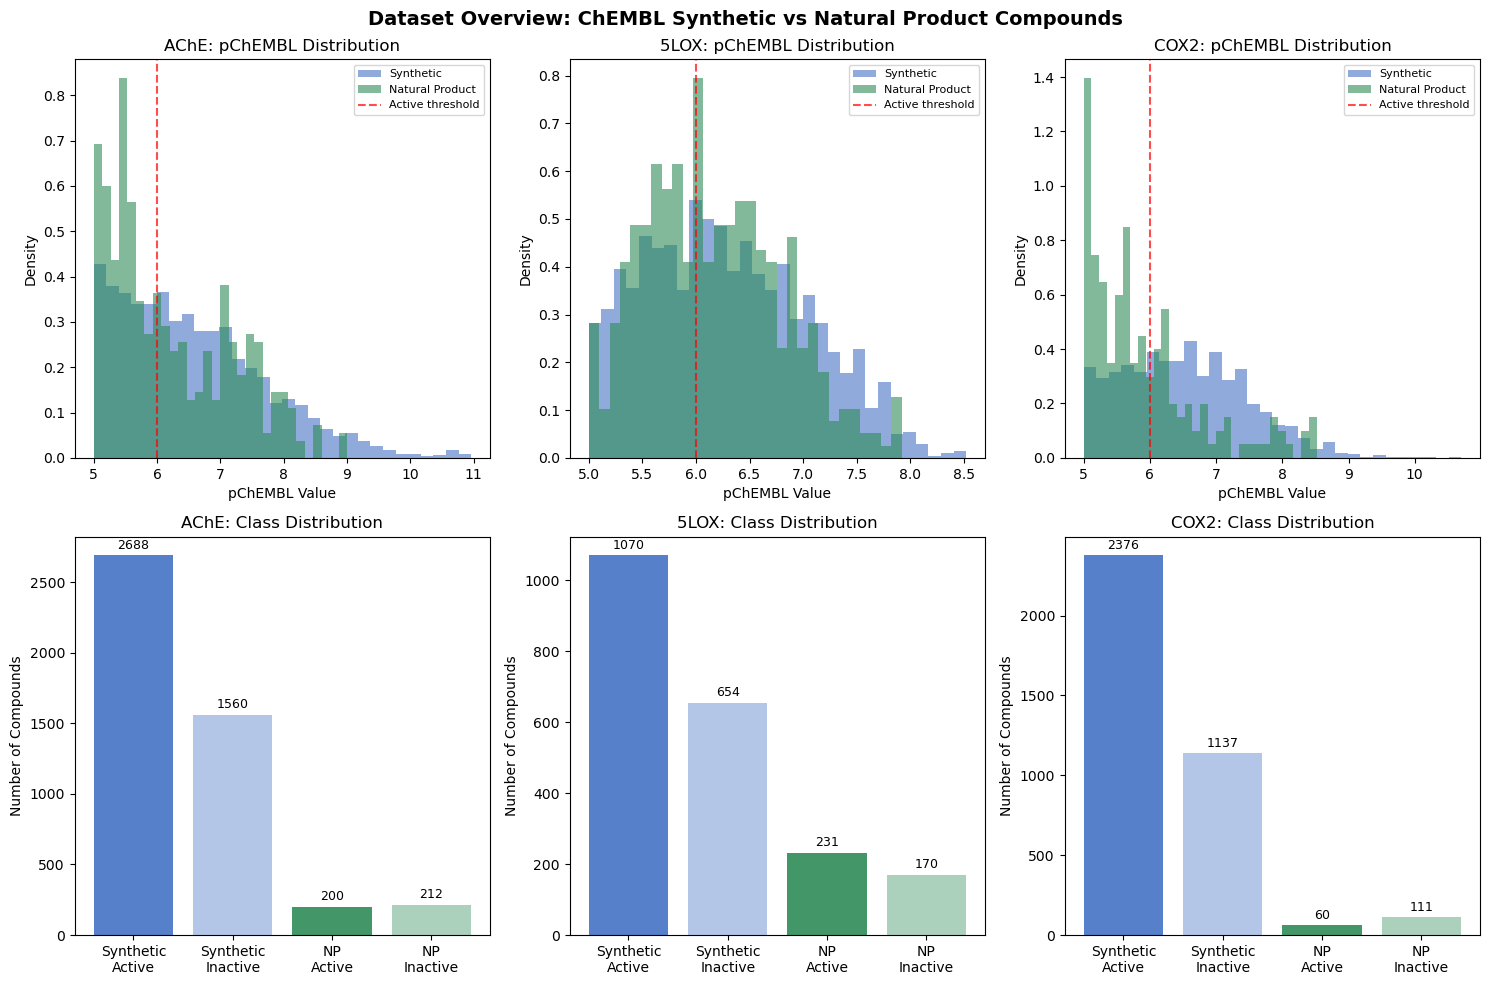

[OK] Dataset overview figure saved.


In [12]:
# ============================================================
# CELL 07: Dataset Quality Visualization
#
# Generate summary plots that will appear in the paper
# as part of the Methods/Results section.
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Dataset Overview: ChEMBL Synthetic vs Natural Product Compounds',
             fontsize=14, fontweight='bold')

colors = {'synthetic': '#4472C4', 'natural_product': '#2E8B57'}

for idx, target_name in enumerate(CONFIG['targets'].keys()):
    if target_name not in syn_dfs or target_name not in np_dfs:
        continue

    syn_df = syn_dfs[target_name]
    np_df = np_dfs[target_name]

    ax_top = axes[0, idx]
    ax_bot = axes[1, idx]

    # Top row: pChEMBL distribution comparison
    ax_top.hist(syn_df['pchembl_value'].dropna(), bins=30, alpha=0.6,
                color=colors['synthetic'], label='Synthetic',
                density=True)
    ax_top.hist(np_df['pchembl_value'].dropna(), bins=30, alpha=0.6,
                color=colors['natural_product'], label='Natural Product',
                density=True)
    ax_top.axvline(CONFIG['pchembl_active'], color='red',
                   linestyle='--', alpha=0.7, label='Active threshold')
    ax_top.set_title(f'{target_name}: pChEMBL Distribution')
    ax_top.set_xlabel('pChEMBL Value')
    ax_top.set_ylabel('Density')
    ax_top.legend(fontsize=8)

    # Bottom row: Class balance
    categories = ['Synthetic\nActive', 'Synthetic\nInactive',
                  'NP\nActive', 'NP\nInactive']
    values = [
        syn_df['activity'].sum(),
        (syn_df['activity'] == 0).sum(),
        np_df['activity'].sum(),
        (np_df['activity'] == 0).sum()
    ]
    bar_colors = [
        colors['synthetic'], colors['synthetic'],
        colors['natural_product'], colors['natural_product']
    ]
    bar_alphas = [0.9, 0.4, 0.9, 0.4]

    bars = ax_bot.bar(categories, values, color=bar_colors)
    for bar, alpha in zip(bars, bar_alphas):
        bar.set_alpha(alpha)
    for bar, val in zip(bars, values):
        ax_bot.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(values) * 0.01,
                    str(val), ha='center', va='bottom', fontsize=9)

    ax_bot.set_title(f'{target_name}: Class Distribution')
    ax_bot.set_ylabel('Number of Compounds')

plt.tight_layout()
plt.savefig(
    Path(CONFIG['output_dir']) / 'dataset_overview.png',
    dpi=300, bbox_inches='tight'
)
plt.show()
print('[OK] Dataset overview figure saved.')

## Cell 08: Export Final Curated Datasets

In [13]:
# ============================================================
# CELL 08: Export Final Curated Datasets
#
# Exports three file types per target:
# 1. {target}_synthetic_train.csv  - ChEMBL synthetic compounds
#                                     (training set for all models)
# 2. {target}_np_test.csv          - Natural product compounds
#                                     (NP holdout test set)
# 3. {target}_combined.csv         - All compounds combined
#                                     (for random/scaffold splits)
#
# Also exports a curation_summary.txt documenting all decisions
# for the Methods section of the paper.
# ============================================================

# Columns to export (keep it clean for Notebook 02)
EXPORT_COLS = [
    'inchikey',
    'std_smiles',
    'pchembl_value',
    'activity',
    'scaffold',
    'compound_type',
    'source',
    'target',
    'np_likeness_score',
    'in_coconut'
]

print('Exporting curated datasets...')
print('=' * 60)

export_summary = []

for target_name in CONFIG['targets'].keys():
    if target_name not in syn_dfs:
        print(f'[SKIP] {target_name} - no data extracted')
        continue

    syn_df = syn_dfs[target_name]
    np_df = np_dfs[target_name]

    # Ensure all export columns exist
    for col in EXPORT_COLS:
        if col not in syn_df.columns:
            syn_df[col] = None
        if col not in np_df.columns:
            np_df[col] = None

    syn_export = syn_df[[c for c in EXPORT_COLS
                          if c in syn_df.columns]].copy()
    np_export = np_df[[c for c in EXPORT_COLS
                         if c in np_df.columns]].copy()
    combined = pd.concat([syn_export, np_export],
                          ignore_index=True)

    # File paths
    syn_path = Path(CONFIG['output_dir']) / f'{target_name}_synthetic_train.csv'
    np_path = Path(CONFIG['output_dir']) / f'{target_name}_np_test.csv'
    comb_path = Path(CONFIG['output_dir']) / f'{target_name}_combined.csv'

    syn_export.to_csv(syn_path, index=False)
    np_export.to_csv(np_path, index=False)
    combined.to_csv(comb_path, index=False)

    print(f'\n{target_name}:')
    print(f'  Synthetic train : {len(syn_export):>5} compounds -> '
          f'{syn_path.name}')
    print(f'  NP test         : {len(np_export):>5} compounds -> '
          f'{np_path.name}')
    print(f'  Combined        : {len(combined):>5} compounds -> '
          f'{comb_path.name}')

    export_summary.append({
        'Target': target_name,
        'Synthetic_n': len(syn_export),
        'Synthetic_active': int(syn_export['activity'].sum()),
        'NP_n': len(np_export),
        'NP_active': int(np_export['activity'].sum()),
        'Combined_n': len(combined)
    })

# Export summary table
summary_df = pd.DataFrame(export_summary)
summary_df.to_csv(
    Path(CONFIG['output_dir']) / 'dataset_summary.csv',
    index=False
)

# ---- Write curation log for Methods section ----
log_path = Path(CONFIG['output_dir']) / 'curation_log.txt'
with open(log_path, 'w') as f:
    f.write('DATA CURATION LOG\n')
    f.write('=' * 60 + '\n')
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"ChEMBL version: 36\n")
    f.write(f"COCONUT version: May 2026\n\n")

    f.write('CURATION DECISIONS\n')
    f.write('-' * 40 + '\n')
    f.write(f"pChEMBL minimum threshold: {CONFIG['pchembl_min']} "
            f"(10 uM cutoff)\n")
    f.write(f"Active/inactive threshold: {CONFIG['pchembl_active']} "
            f"(1 uM cutoff)\n")
    f.write(f"Duplicate handling: median pChEMBL per InChIKey\n")
    f.write(f"Standardization: RDKit (largest fragment, "
            f"neutralization, canonical SMILES)\n")
    f.write(f"NP classification: COCONUT membership OR "
            f"NP-likeness score >= {CONFIG['np_likeness_threshold']}\n")
    f.write(f"Deduplication: full InChIKey + connectivity "
            f"layer (tautomers)\n\n")

    f.write('DATASET SIZES\n')
    f.write('-' * 40 + '\n')
    f.write(summary_df.to_string(index=False))

print(f'\n[OK] Curation log saved to: {log_path}')
print('\n' + '=' * 60)
print('NOTEBOOK 01 COMPLETE')
print('=' * 60)
print('\nFiles ready for Notebook 02 (upload to Google Drive):')
for f in Path(CONFIG['output_dir']).glob('*.csv'):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:45s} {size_kb:8.1f} KB')

Exporting curated datasets...

AChE:
  Synthetic train :  4248 compounds -> AChE_synthetic_train.csv
  NP test         :   412 compounds -> AChE_np_test.csv
  Combined        :  4660 compounds -> AChE_combined.csv

5LOX:
  Synthetic train :  1724 compounds -> 5LOX_synthetic_train.csv
  NP test         :   401 compounds -> 5LOX_np_test.csv
  Combined        :  2125 compounds -> 5LOX_combined.csv

COX2:
  Synthetic train :  3513 compounds -> COX2_synthetic_train.csv
  NP test         :   171 compounds -> COX2_np_test.csv
  Combined        :  3684 compounds -> COX2_combined.csv

[OK] Curation log saved to: C:\Users\PC\Documents\inha_qsar_project\Domain shift\np_qsar_project\data\curation_log.txt

NOTEBOOK 01 COMPLETE

Files ready for Notebook 02 (upload to Google Drive):
  5LOX_combined.csv                                330.7 KB
  5LOX_np_test.csv                                  60.9 KB
  5LOX_synthetic_train.csv                         269.9 KB
  AChE_combined.csv                      

## Cell 09: Data Integrity Verification

Final checks before handing off to Notebook 02. Run this before uploading to Google Drive.

In [14]:
# ============================================================
# CELL 09: Data Integrity Verification
#
# Automated checks that would catch the most common errors
# that reviewers look for in benchmarking papers:
# 1. No data leakage between train and test sets
# 2. No missing values in critical columns
# 3. Sufficient class representation in both sets
# 4. SMILES are valid RDKit-parseable strings
# ============================================================

print('Running data integrity checks...')
print('=' * 60)

all_checks_passed = True

for target_name in CONFIG['targets'].keys():
    if target_name not in syn_dfs:
        continue

    syn_df = syn_dfs[target_name]
    np_df = np_dfs[target_name]

    print(f'\n{target_name}:')
    target_passed = True

    # Check 1: No InChIKey overlap between train and test
    syn_keys = set(syn_df['inchikey'].dropna())
    np_keys = set(np_df['inchikey'].dropna())
    overlap = syn_keys & np_keys
    if len(overlap) == 0:
        print(f'  [PASS] No InChIKey overlap between train and NP test')
    else:
        print(f'  [FAIL] {len(overlap)} compounds overlap between '
              f'train and NP test!')
        target_passed = False

    # Check 2: No missing SMILES
    syn_null_smi = syn_df['std_smiles'].isna().sum()
    np_null_smi = np_df['std_smiles'].isna().sum()
    if syn_null_smi == 0 and np_null_smi == 0:
        print(f'  [PASS] No missing SMILES in either set')
    else:
        print(f'  [FAIL] Missing SMILES: {syn_null_smi} synthetic, '
              f'{np_null_smi} NP')
        target_passed = False

    # Check 3: Both classes present in both sets
    syn_classes = syn_df['activity'].nunique()
    np_classes = np_df['activity'].nunique()
    if syn_classes == 2:
        print(f'  [PASS] Both activity classes present in synthetic set')
    else:
        print(f'  [WARN] Only {syn_classes} class(es) in synthetic set')
    if np_classes == 2:
        print(f'  [PASS] Both activity classes present in NP set')
    else:
        print(f'  [WARN] Only {np_classes} class(es) in NP set '
              f'- may affect MCC calculation')

    # Check 4: Minimum size
    if len(syn_df) >= CONFIG['min_compounds_chembl']:
        print(f'  [PASS] Synthetic set size: {len(syn_df)} '
              f'(>= {CONFIG["min_compounds_chembl"]})')
    else:
        print(f'  [WARN] Synthetic set size: {len(syn_df)} '
              f'(< {CONFIG["min_compounds_chembl"]})')

    if len(np_df) >= CONFIG['min_compounds_np']:
        print(f'  [PASS] NP set size: {len(np_df)} '
              f'(>= {CONFIG["min_compounds_np"]})')
    else:
        print(f'  [WARN] NP set size: {len(np_df)} '
              f'(< {CONFIG["min_compounds_np"]}) - consider fallback')

    # Check 5: SMILES parseable by RDKit
    sample = syn_df['std_smiles'].dropna().sample(
        min(50, len(syn_df)), random_state=CONFIG['seed']
    )
    parse_failures = sum(
        1 for s in sample if Chem.MolFromSmiles(s) is None
    )
    if parse_failures == 0:
        print(f'  [PASS] SMILES parse check passed (50-compound sample)')
    else:
        print(f'  [FAIL] {parse_failures}/50 sampled SMILES fail RDKit parse')
        target_passed = False

    if not target_passed:
        all_checks_passed = False

print('\n' + '=' * 60)
if all_checks_passed:
    print('[ALL CHECKS PASSED]')
    print('Data is ready for upload to Google Drive and Notebook 02.')
else:
    print('[SOME CHECKS FAILED]')
    print('Review FAIL messages above before proceeding to Notebook 02.')
print('=' * 60)

Running data integrity checks...

AChE:
  [PASS] No InChIKey overlap between train and NP test
  [PASS] No missing SMILES in either set
  [PASS] Both activity classes present in synthetic set
  [PASS] Both activity classes present in NP set
  [PASS] Synthetic set size: 4248 (>= 200)
  [PASS] NP set size: 412 (>= 50)
  [PASS] SMILES parse check passed (50-compound sample)

5LOX:
  [PASS] No InChIKey overlap between train and NP test
  [PASS] No missing SMILES in either set
  [PASS] Both activity classes present in synthetic set
  [PASS] Both activity classes present in NP set
  [PASS] Synthetic set size: 1724 (>= 200)
  [PASS] NP set size: 401 (>= 50)
  [PASS] SMILES parse check passed (50-compound sample)

COX2:
  [PASS] No InChIKey overlap between train and NP test
  [PASS] No missing SMILES in either set
  [PASS] Both activity classes present in synthetic set
  [PASS] Both activity classes present in NP set
  [PASS] Synthetic set size: 3513 (>= 200)
  [PASS] NP set size: 171 (>= 50)


---

## End of Notebook 01

### Files to upload to Google Drive before running Notebook 02

Upload the entire output directory. Required files per target:
- `{target}_synthetic_train.csv`
- `{target}_np_test.csv`
- `{target}_combined.csv`

Also upload:
- `dataset_summary.csv`
- `deduplication_report.csv`
- `curation_log.txt`

### Methods section text (draft)

The following text can be adapted directly from this notebook for your paper:

> Bioactivity data for three targets (AChE, CHEMBL220; InhA, CHEMBL2366452; COX-2, CHEMBL230) were extracted from ChEMBL 36 (SQLite local instance) using direct SQL queries restricted to single-protein targets, IC50 and Ki measurement types, pChEMBL values >= 5.0, and assay confidence scores >= 8. SMILES were standardized using RDKit (version X.X): salts were removed by retaining the largest fragment, charges were neutralized using a rule-based approach, and canonical SMILES were generated. Duplicate molecules were identified by InChIKey and consolidated by taking the median pChEMBL value across replicate measurements. Binary activity labels were assigned at a pChEMBL threshold of 6.0 (corresponding to IC50/Ki <= 1 uM). Natural product compounds were identified by membership in the COCONUT 2.0 database (May 2026 release) or by NP-likeness score >= 0.5 as calculated by the Ertl NP scorer implemented in RDKit. Cross-set deduplication was performed using full InChIKey matching and connectivity-layer matching (first 14 characters) to remove potential tautomeric overlaps between the synthetic training set and the natural product test set.